# Task 2 - Exploratory Data Analysis (EDA)
**Dataset:** Cleaned Telco Customer Churn (from Task 1)  
In this task, I conducted Exploratory Data Analysis (EDA) on the cleaned dataset obtained from Task 1.

The purpose of EDA is to understand the distribution of features, identify patterns, and examine relationships between variables before proceeding to modelling.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('cleaned_churn_data.csv')
print("Loaded dataset:", df.shape)
df.head()

Loaded dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Section 1: Overall Churn Rate
In this section, I calculated the overall churn rate of customers.

To understand it clearly, I visualized the results using:
- A donut chart to show the percentage distribution
- A bar chart to display the total number of churned vs non-churned customers

In [ ]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].mean() * 100

print("Churn breakdown:")
print(f"  Retained: {churn_counts[0]:,} customers")
print(f"  Churned:  {churn_counts[1]:,} customers")
print(f"  Overall churn rate: {churn_rate:.1f}%")
print()
print("NOTE: Industry average churn is ~15-20%. At 26%, this company is losing customers faster than average.")

Churn breakdown:
  Retained: 5,174 customers
  Churned:  1,869 customers
  Overall churn rate: 26.5%

NOTE: Industry average churn is ~15-20%. At 26%, this company is losing customers faster than average.


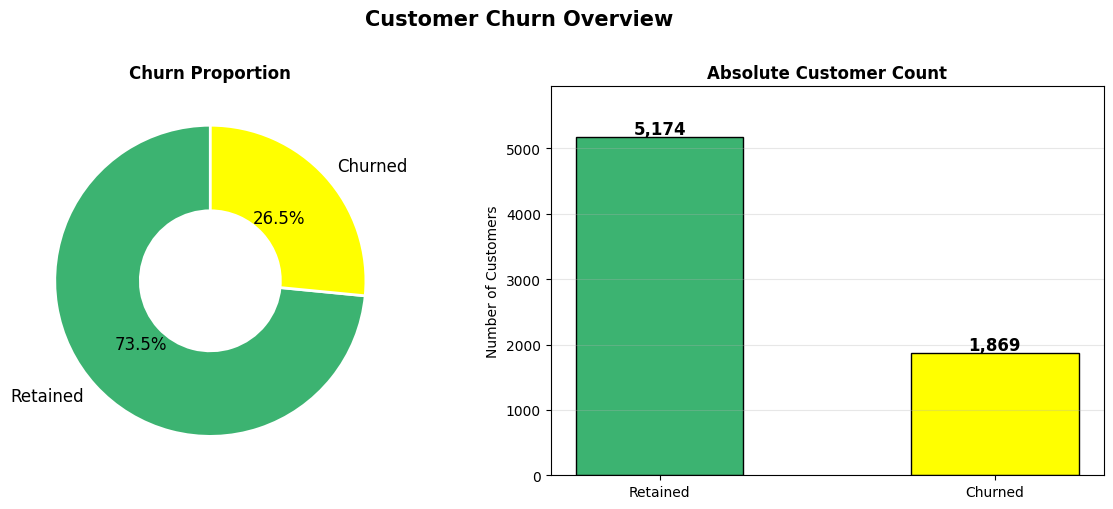

Chart saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Customer Churn Overview', fontsize=15, fontweight='bold', y=1.01)

# donut chart - shows proportion
axes[0].pie(
    churn_counts.values,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    colors=['mediumseagreen', 'yellow'],
    startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
axes[0].set_title('Churn Proportion', fontsize=12, fontweight='bold')

# bar chart - shows actual counts
bars = axes[1].bar(
    ['Retained', 'Churned'],
    churn_counts.values,
    color=['mediumseagreen', 'yellow'],
    edgecolor='black', width=0.5
)
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Absolute Customer Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(churn_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('eda_01_churn_overview.png', bbox_inches='tight', dpi=120)
plt.show()
print("Chart saved.")

## Section 2: Churn by Customer Demographics
In this section, I analyzed churn distribution across different demographic features such as:
- Gender
- Senior Citizen status
- Partner
- Dependents

The objective is to examine whether churn varies significantly among different customer groups.

In [ ]:
print("Churn rates by key demographics:")
print()
for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents']:
    rates = df.groupby(col)['Churn'].mean().mul(100).round(1)
    print(f"{col}:")
    print(rates.to_string())
    print()

Churn rates by key demographics:

gender:
gender
Female    26.9
Male      26.2

SeniorCitizen:
SeniorCitizen
0    23.6
1    41.7

Partner:
Partner
No     33.0
Yes    19.7

Dependents:
Dependents
No     31.3
Yes    15.5



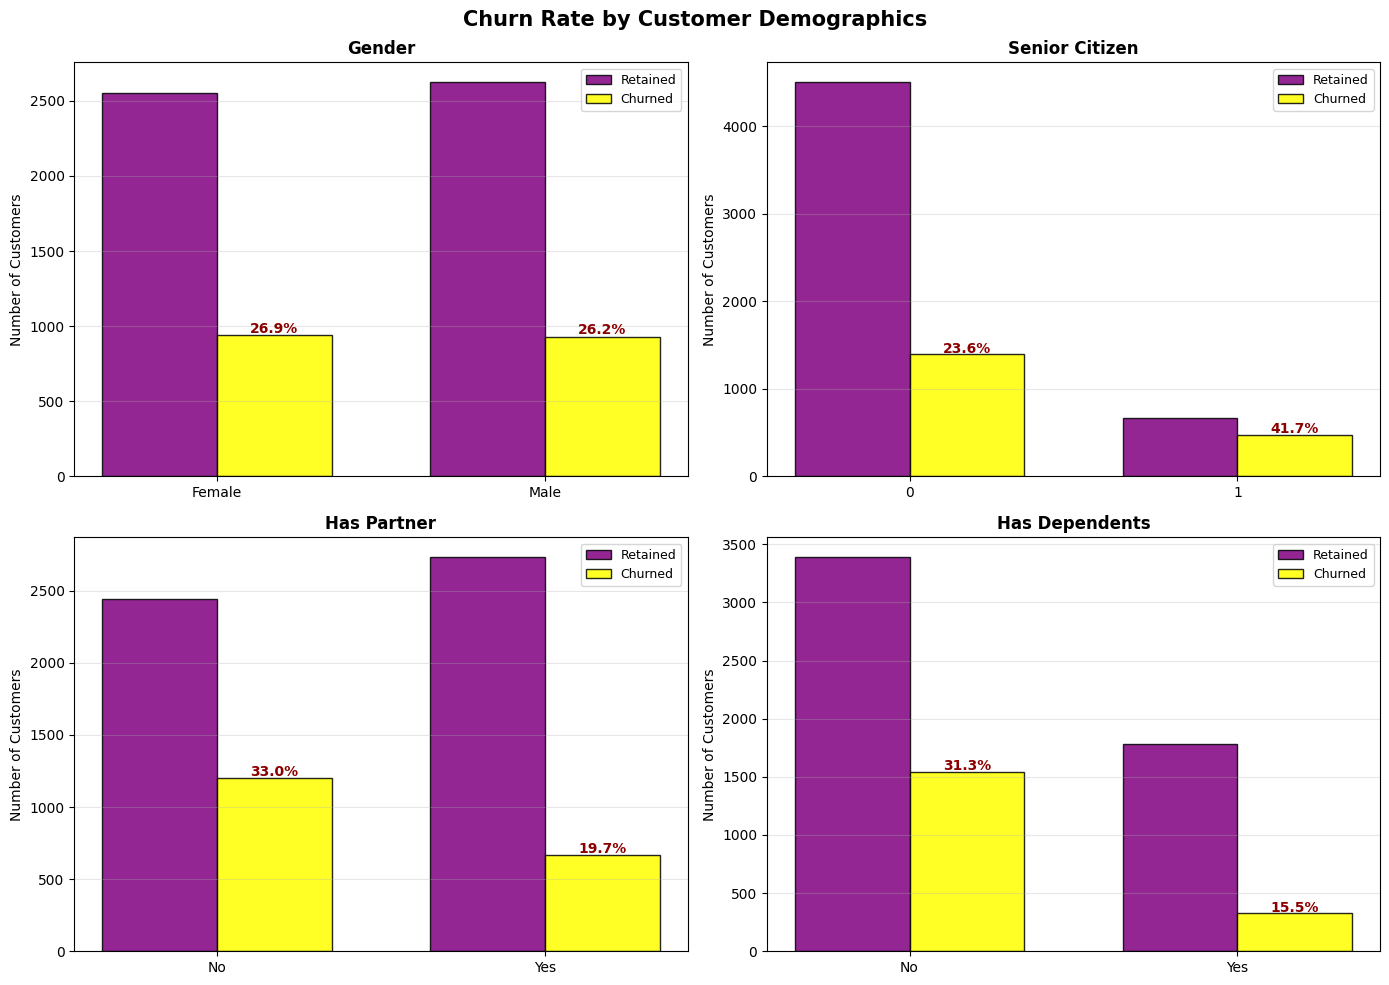

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Rate by Customer Demographics', fontsize=15, fontweight='bold')

demo_cols = [('gender', 'Gender'), ('SeniorCitizen', 'Senior Citizen'), 
             ('Partner', 'Has Partner'), ('Dependents', 'Has Dependents')]

for ax, (col, title) in zip(axes.flatten(), demo_cols):
    grp = df.groupby(col)['Churn'].agg(['mean', 'count']).reset_index()
    grp.columns = [col, 'ChurnRate', 'Count']
    grp['ChurnRate'] = grp['ChurnRate'] * 100
    grp['Retained'] = grp['Count'] * (1 - grp['ChurnRate']/100)
    grp['Churned'] = grp['Count'] * grp['ChurnRate']/100

    x = range(len(grp))
    w = 0.35
    ax.bar([i - w/2 for i in x], grp['Retained'], w, label='Retained', color='purple', edgecolor='black', alpha=0.85)
    bars2 = ax.bar([i + w/2 for i in x], grp['Churned'], w, label='Churned', color='yellow', edgecolor='black', alpha=0.85)

    for bar, rate in zip(bars2, grp['ChurnRate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f'{rate:.1f}%', ha='center', fontsize=10, color='darkred', fontweight='bold')

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(grp[col].astype(str))
    ax.set_ylabel('Number of Customers')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_02_demographics.png', bbox_inches='tight', dpi=120)
plt.show()

## Section 3: Tenure Analysis
In this section, I analyzed the relationship between customer tenure and churn.

The goal is to examine whether customers with lower tenure are more likely to churn compared to long-term customers.

To visualize this, I used:
- A histogram to observe the distribution
- A box plot to compare tenure between churned and non-churned customers

In [ ]:
print("Tenure stats by churn status:")
print(df.groupby('Churn')['tenure'].describe().round(1))
print()
print("Median tenure - Retained:", df[df['Churn']==0]['tenure'].median(), "months")
print("Median tenure - Churned:", df[df['Churn']==1]['tenure'].median(), "months")
print()
diff = df[df['Churn']==0]['tenure'].median() - df[df['Churn']==1]['tenure'].median()
print(f"Difference: {diff:.0f} months - churned customers leave almost 3x sooner on average")

Tenure stats by churn status:
        count  mean   std  min   25%   50%   75%   max
Churn                                                 
0      5174.0  37.6  24.1  0.0  15.0  38.0  61.0  72.0
1      1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0

Median tenure - Retained: 38.0 months
Median tenure - Churned: 10.0 months

Difference: 28 months - churned customers leave almost 3x sooner on average


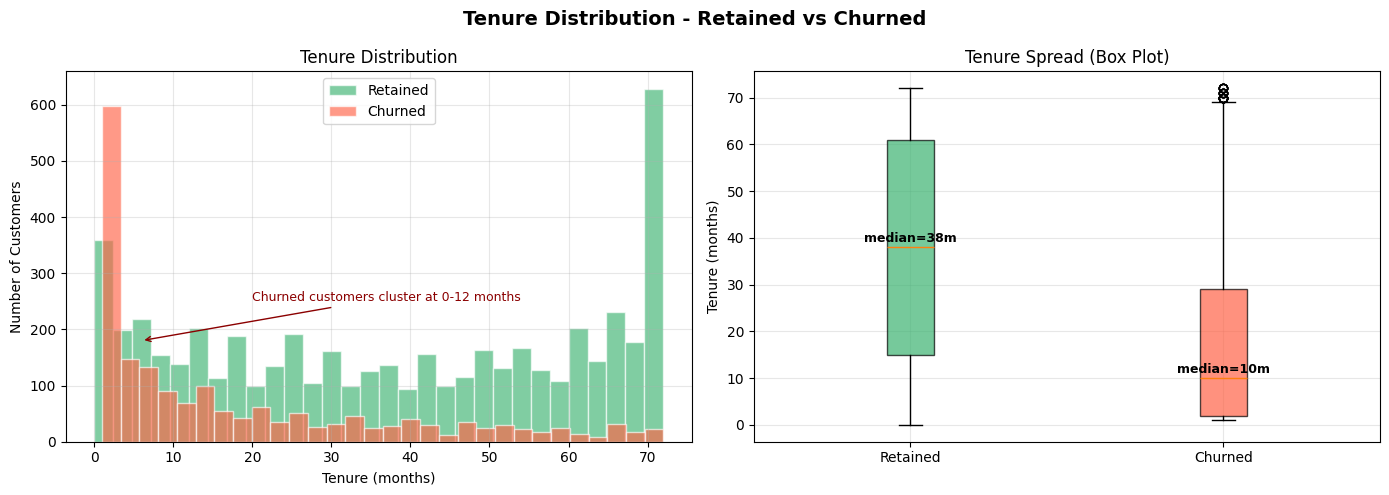

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tenure Distribution - Retained vs Churned', fontsize=14, fontweight='bold')

# histogram shows the shape of the distribution
for val, label, color in zip([0, 1], ['Retained', 'Churned'], ['mediumseagreen', 'tomato']):
    axes[0].hist(df[df['Churn']==val]['tenure'], bins=30, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Tenure Distribution')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].annotate('Churned customers cluster at 0-12 months', xy=(6, 180),
                 fontsize=9, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred'),
                 xytext=(20, 250))

# box plot shows the spread and median clearly
bp = axes[1].boxplot(
    [df[df['Churn']==0]['tenure'], df[df['Churn']==1]['tenure']],
    labels=['Retained', 'Churned'], patch_artist=True, notch=False
)
for patch, color in zip(bp['boxes'], ['mediumseagreen', 'tomato']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Tenure Spread (Box Plot)')
axes[1].set_ylabel('Tenure (months)')
axes[1].grid(alpha=0.3)
for i, label in enumerate(['Retained', 'Churned'], 1):
    med = df[df['Churn']==(i-1)]['tenure'].median()
    axes[1].text(i, med + 1, f'median={med:.0f}m', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_03_tenure.png', bbox_inches='tight', dpi=120)
plt.show()

## Section 4: Contract Type and Payment Method
In this section, I analyzed churn across different contract types and payment methods.

The objective is to examine whether contract duration and payment method are associated with customer churn.

In [ ]:
print("Churn rate by Contract Type:")
print(df.groupby('Contract')['Churn'].mean().mul(100).round(1).to_string())
print()
print("Churn rate by Payment Method:")
print(df.groupby('PaymentMethod')['Churn'].mean().mul(100).round(1).sort_values(ascending=False).to_string())

Churn rate by Contract Type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

Churn rate by Payment Method:
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2


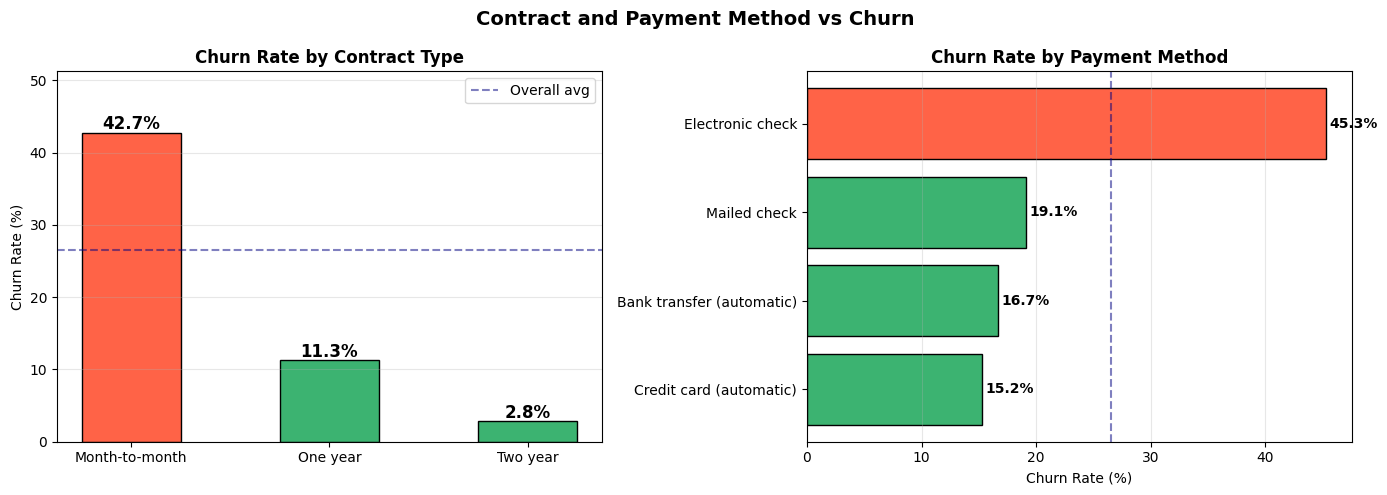

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Contract and Payment Method vs Churn', fontsize=14, fontweight='bold')

# contract type - coloured by risk level
contract_churn = df.groupby('Contract')['Churn'].mean().mul(100).sort_values(ascending=False)
colors = ['tomato' if v > 35 else 'darkorange' if v > 15 else 'mediumseagreen' for v in contract_churn.values]
bars = axes[0].bar(contract_churn.index, contract_churn.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, contract_churn.max() * 1.2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(df['Churn'].mean()*100, color='navy', linestyle='--', alpha=0.5, label='Overall avg')
axes[0].legend()

# payment method - horizontal bar
pay_churn = df.groupby('PaymentMethod')['Churn'].mean().mul(100).sort_values()
pcolors = ['tomato' if v > 40 else 'darkorange' if v > 20 else 'mediumseagreen' for v in pay_churn.values]
hbars = axes[1].barh(pay_churn.index, pay_churn.values, color=pcolors, edgecolor='black')
for bar, val in zip(hbars, pay_churn.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')
axes[1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
axes[1].grid(axis='x', alpha=0.3)
axes[1].axvline(df['Churn'].mean()*100, color='navy', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('eda_04_contract_payment.png', bbox_inches='tight', dpi=120)
plt.show()

## Section 5: Monthly Charges Analysis
Here, I examined whether monthly charges differ across churn categories.

A violin plot was used to visualize the distribution of monthly charges for churned and non-churned customers.

In [ ]:
print("Average charges by churn status:")
print(df.groupby('Churn')[['MonthlyCharges','TotalCharges']].mean().round(2))

Average charges by churn status:
       MonthlyCharges  TotalCharges
Churn                              
0               61.27       2555.34
1               74.44       1531.80


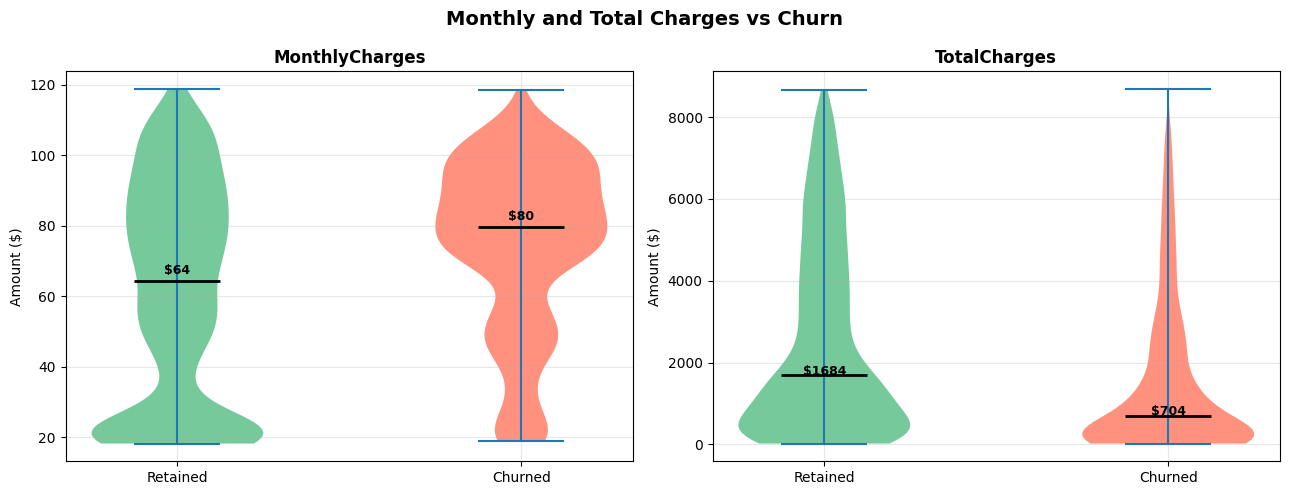

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Monthly and Total Charges vs Churn', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['MonthlyCharges', 'TotalCharges']):
    parts = ax.violinplot(
        [df[df['Churn']==0][col].dropna(), df[df['Churn']==1][col].dropna()],
        showmedians=True, showmeans=False
    )
    for pc, color in zip(parts['bodies'], ['mediumseagreen', 'tomato']):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Amount ($)')
    ax.grid(alpha=0.3)
    # add median labels
    for i, val in enumerate([0, 1], 1):
        med = df[df['Churn']==val][col].median()
        ax.text(i, med + 2, f'${med:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_05_charges.png', bbox_inches='tight', dpi=120)
plt.show()

## Section 6: Correlation Analysis
Here, I used a correlation matrix to analyze relationships between numeric features in the dataset.

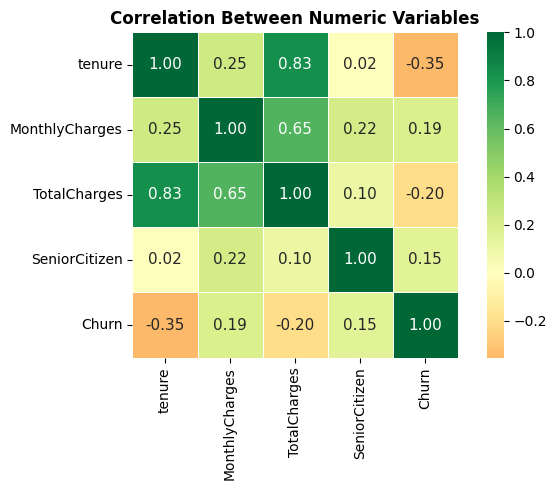

Correlation with Churn (sorted):
tenure           -0.352
TotalCharges     -0.199
SeniorCitizen     0.151
MonthlyCharges    0.193
Name: Churn, dtype: float64


In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = False
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 11})
plt.title('Correlation Between Numeric Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_correlation.png', bbox_inches='tight', dpi=120)
plt.show()

print("Correlation with Churn (sorted):")
print(corr['Churn'].drop('Churn').sort_values().round(3))

## Summary of Key Findings

In [ ]:
print("=" * 50)
print("TASK 2 - KEY FINDINGS SUMMARY")
print("=" * 50)
print()
print(f"1. Overall churn rate: {df['Churn'].mean()*100:.1f}% (industry avg is ~15-20%)")
print()
print(f"2. Contract type is the biggest factor:  # this was the clearest pattern in the whole dataset")
for c, r in df.groupby('Contract')['Churn'].mean().mul(100).items():
    print(f"   {c}: {r:.1f}% churn")
print()
print(f"3. Tenure gap is dramatic:")
print(f"   Churned customers median tenure: {df[df['Churn']==1]['tenure'].median():.0f} months")
print(f"   Retained customers median tenure: {df[df['Churn']==0]['tenure'].median():.0f} months")
print()
print(f"4. Electronic check payment: highest churn at {df[df['PaymentMethod']=='Electronic check']['Churn'].mean()*100:.1f}%")
print()
print(f"5. Senior citizens churn more: {df[df['SeniorCitizen']==1]['Churn'].mean()*100:.1f}% vs {df[df['SeniorCitizen']==0]['Churn'].mean()*100:.1f}%")

TASK 2 - KEY FINDINGS SUMMARY

1. Overall churn rate: 26.5% (industry avg is ~15-20%)

2. Contract type is the biggest factor:  # this was the clearest pattern in the whole dataset
   Month-to-month: 42.7% churn
   One year: 11.3% churn
   Two year: 2.8% churn

3. Tenure gap is dramatic:
   Churned customers median tenure: 10 months
   Retained customers median tenure: 38 months

4. Electronic check payment: highest churn at 45.3%

5. Senior citizens churn more: 41.7% vs 23.6%
